# Retail Customer Segmentation (IT3091, Group 2026-AI-20)
# Primary lens: customer segmentation. Secondary lens: customer value / retention.
# Unit of analysis: one identifiable customer. Learning type: unsupervised clustering.

In [1]:
import sys
import os
import pandas as pd

# Resolve dynamic project root path
try:
    notebook_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    notebook_dir = os.getcwd()

if os.path.basename(notebook_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
else:
    project_root = os.path.abspath(notebook_dir)

# Append src directory to sys.path
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Ensure required directory structure exists
os.makedirs(os.path.join(project_root, 'outputs', 'tables'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'outputs', 'figures'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'data', 'processed'), exist_ok=True)

# Import module functions
from cleaning import audit_and_clean_data, compute_file_sha256

raw_data_path = os.path.join(project_root, "data", "raw", "Online Retail.xlsx")
# Display clean relative path for Git submission
rel_display_path = os.path.relpath(raw_data_path, project_root)
print(f"Loading dataset from: {rel_display_path}")
# Run data cleaning pipeline
df_clean, audit_df, returns_df = audit_and_clean_data(raw_data_path, return_audit=True)

# Export audit table and preserved returns
audit_df.to_csv(os.path.join(project_root, 'outputs', 'tables', 'cleaning_audit.csv'), index=False)
returns_df.to_csv(os.path.join(project_root, 'data', 'processed', 'returns.csv'), index=False)

# Compute SHA-256 fingerprint for verification
sha256_hash = compute_file_sha256(raw_data_path)
print("-" * 35)
print("Dataset Reproducibility Metadata")
print("-" * 35)
print(f"File: Online Retail.xlsx")
print(f"SHA-256 Hash: {sha256_hash}")
print("-" * 35)

# Display final cleaned summary
print("\nFinal Cohort Summary")
print("-" * 25)
print(f"Sales Transactions: {df_clean.shape[0]:,}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Unique Customers: {df_clean['CustomerID'].nunique():,}")
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(f"Date Range: {df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}")
print("-" * 25)

# Render audit log
audit_df

Loading dataset from: data\raw\Online Retail.xlsx
-----------------------------------
Dataset Reproducibility Metadata
-----------------------------------
File: Online Retail.xlsx
SHA-256 Hash: 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d
-----------------------------------

Final Cohort Summary
-------------------------
Sales Transactions: 391,283
Columns: 9
Unique Customers: 4,334
Date Range: 2010-12-01 to 2011-12-09
-------------------------


,Stage,Rows_Retained,Rows_Dropped,Unique_Customers,Description
0,0. Ingestion (Raw Data),541909,0,4372,Raw unedited data loaded directly from source ...
1,1. CustomerID Imputation Filter,406829,135080,4372,Filtered records missing CustomerID where beha...
2,2. Duplicate Deduplication,401604,5225,4372,Dropped exact duplicate transactions across al...
3,3. Non-Merchandise Removal,399823,1781,4363,"Removed postage, discount adjustments, debt wr..."
4,4. Valid Positive Sales Cohort,391283,8540,4334,"Filtered out returns, zero/negative quantities..."


In [6]:
import importlib
import features
importlib.reload(features)

from features import create_rfm_features
from sklearn.preprocessing import StandardScaler

# Generate RFM metrics using fixed reference date
rfm_df = create_rfm_features(df_clean, reference_date='2011-12-10')

# Apply scaling locally to avoid double-scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_df[['Recency_log', 'Frequency_log', 'Monetary_log']])

rfm_df['R_scaled'] = X_scaled[:, 0]
rfm_df['F_scaled'] = X_scaled[:, 1]
rfm_df['M_scaled'] = X_scaled[:, 2]

# Export intermediate RFM dataset
rfm_df.to_csv(os.path.join(project_root, 'data', 'processed', 'customer_rfm.csv'), index=False)

print(f"RFM Dataframe Shape: {rfm_df.shape}")
rfm_df.head()

RFM Dataframe Shape: (4334, 10)


,CustomerID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,R_scaled,F_scaled,M_scaled
0,12346,326,1,77183.60,5.789960,0.693147,11.253955,1.477298,-0.951243,3.729311
1,12347,3,7,4310.00,1.386294,2.079442,8.368925,-1.890934,1.082163,1.429190
2,12348,76,4,1437.24,4.343805,1.609438,7.271175,0.371177,0.392765,0.553997
3,12349,19,1,1457.55,2.995732,0.693147,7.285198,-0.659923,-0.951243,0.565177
4,12350,311,1,294.40,5.743003,0.693147,5.688330,1.441382,-0.951243,-0.707943


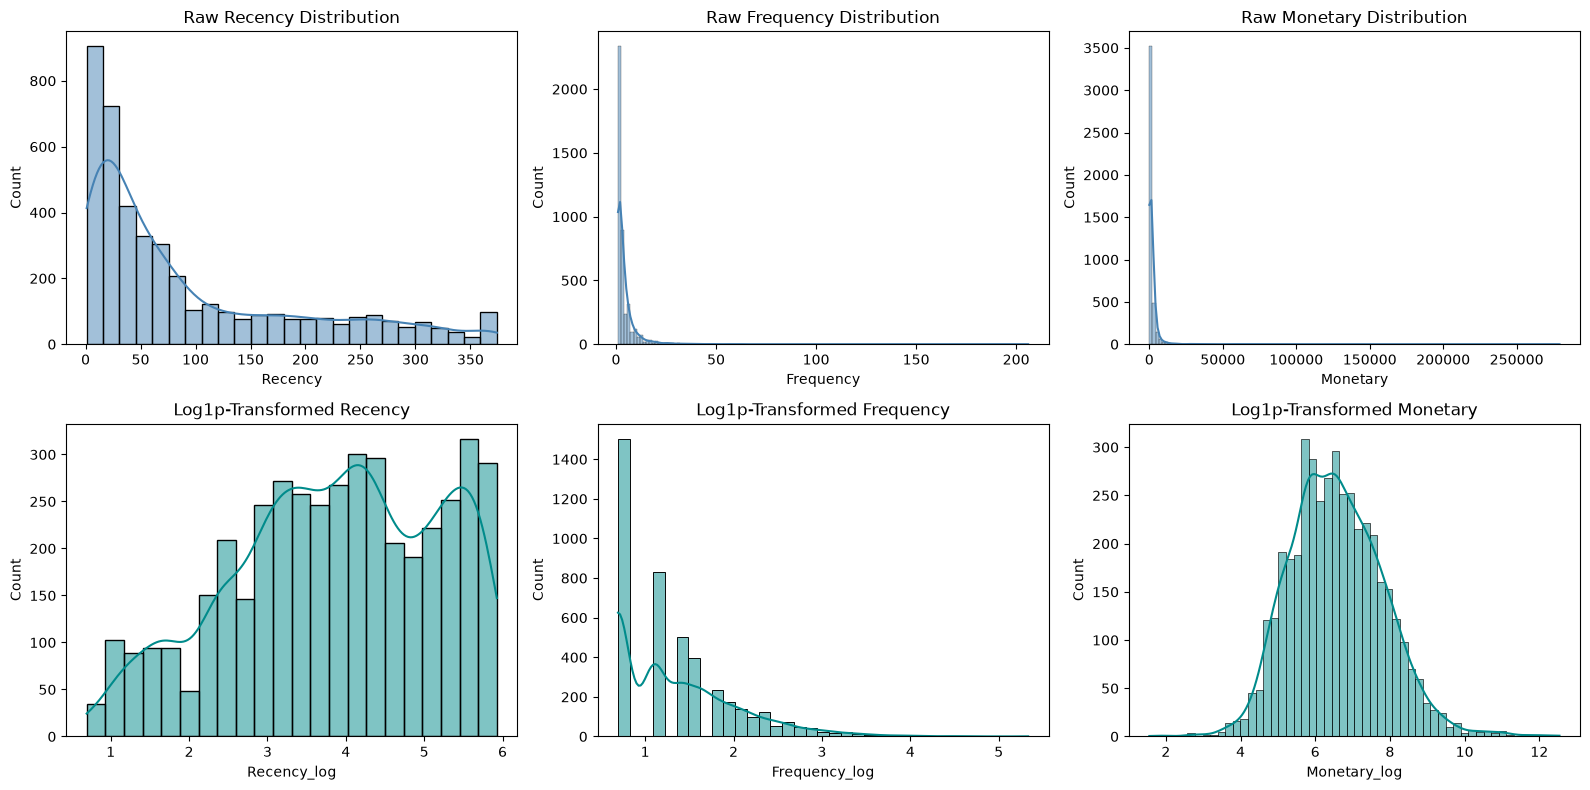

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
features = ['Recency', 'Frequency', 'Monetary']

for idx, feat in enumerate(features):
    # Plot raw feature distribution
    sns.histplot(rfm_df[feat], kde=True, ax=axes[0, idx], color='steelblue')
    axes[0, idx].set_title(f'Raw {feat} Distribution')
    
    # Plot log-transformed feature distribution
    sns.histplot(rfm_df[f'{feat}_log'], kde=True, ax=axes[1, idx], color='darkcyan')
    axes[1, idx].set_title(f'Log1p-Transformed {feat}')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'figures', 'rfm_distributions_eda.png'), dpi=300)
plt.show()

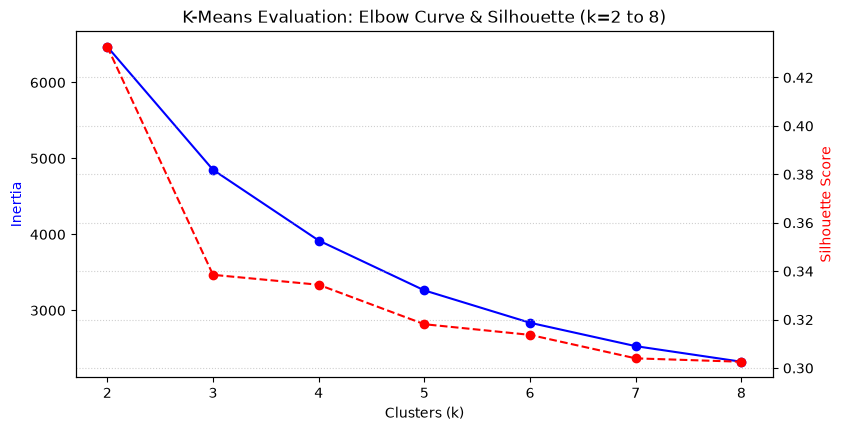

,k,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Smallest_Cluster_%
0,2,6470.28,0.4327,0.8905,4373.16,38.37
1,3,4850.20,0.3385,1.0402,3639.64,17.31
2,4,3919.47,0.3344,1.0175,3344.64,16.71
3,5,3262.77,0.3181,0.9814,3230.54,8.28
4,6,2836.43,0.3137,1.0127,3102.29,7.82
5,7,2528.50,0.3040,0.9893,2987.24,4.98
6,8,2323.28,0.3026,0.9912,2840.58,4.96


In [10]:
import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import evaluate_k_range
import matplotlib.pyplot as plt

# Compute cluster validity metrics across k range
k_study_df = evaluate_k_range(X_scaled, k_range=range(2, 9), seed=42)
k_study_df.to_csv(os.path.join(project_root, 'outputs', 'tables', 'k_selection_study.csv'), index=False)

# Plot Elbow and Silhouette evaluation curve
fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.plot(k_study_df['k'], k_study_df['Inertia'], 'bo-', label='Inertia')
ax1.set_xlabel('Clusters (k)')
ax1.set_ylabel('Inertia', color='blue')

ax2 = ax1.twinx()
ax2.plot(k_study_df['k'], k_study_df['Silhouette'], 'ro--', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='red')

plt.title('K-Means Evaluation: Elbow Curve & Silhouette (k=2 to 8)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(os.path.join(project_root, 'outputs', 'figures', 'k_selection_curve.png'), dpi=300)
plt.show()

k_study_df

In [11]:
import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import evaluate_models

# Run baseline model and clustering candidate models
comparison_df, labels_dict = evaluate_models(X_scaled, rfm_df=rfm_df, k=4, seeds=(42, 100, 2026))

comparison_df.to_csv(os.path.join(project_root, 'outputs', 'tables', 'model_comparison.csv'), index=False)
comparison_df

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz,Smallest_Cluster_%,Stability_ARI (Subsample)
0,RFM 4-Quantile Baseline,0.1959,1.7956,2372.54,18.00,Deterministic (Rule-based)
1,K-Means (k=4),0.3344,1.0175,3344.64,16.71,0.9176 ± 0.0379
2,Agglomerative (k=4),0.2672,1.1444,2746.09,14.54,0.4200 ± 0.0624
3,Gaussian Mixture (k=4),0.1721,1.7251,2154.39,19.17,0.9217 ± 0.0456


In [12]:
# Assign K-Means (k=4) cluster labels
rfm_df['Cluster'] = labels_dict['K-Means (k=4)']

# Export customer segments with CustomerID intact
rfm_df[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster']].to_csv(
    os.path.join(project_root, 'outputs', 'tables', 'customer_segments.csv'), 
    index=False
)

# Aggregate profiling statistics
profiles = rfm_df.groupby('Cluster').agg({
    'Recency': ['median', lambda x: x.quantile(0.75) - x.quantile(0.25)],
    'Frequency': ['median', lambda x: x.quantile(0.75) - x.quantile(0.25)],
    'Monetary': ['median', lambda x: x.quantile(0.75) - x.quantile(0.25), 'sum'],
    'CustomerID': 'count'
})

profiles.columns = [
    'Recency_Median', 'Recency_IQR',
    'Freq_Median', 'Freq_IQR',
    'Monetary_Median', 'Monetary_IQR',
    'Total_Revenue', 'Customer_Count'
]

profiles['Customer_Share_%'] = (profiles['Customer_Count'] / len(rfm_df)) * 100
profiles['Revenue_Share_%'] = (profiles['Total_Revenue'] / profiles['Total_Revenue'].sum()) * 100

# Save final cluster profiles
profiles.to_csv(os.path.join(project_root, 'outputs', 'tables', 'cluster_profiles.csv'))

# Display profile table
profiles[['Customer_Count', 'Customer_Share_%', 'Revenue_Share_%', 'Recency_Median', 'Freq_Median', 'Monetary_Median']]

,Customer_Count,Customer_Share_%,Revenue_Share_%,Recency_Median,Freq_Median,Monetary_Median
Cluster,,,,,,
0,724,16.705122,65.021020,9.0,10.0,3596.850
1,1548,35.717582,6.251758,186.0,1.0,300.045
2,1175,27.111214,23.789220,53.0,4.0,1334.340
3,887,20.466082,4.938002,20.0,2.0,413.590


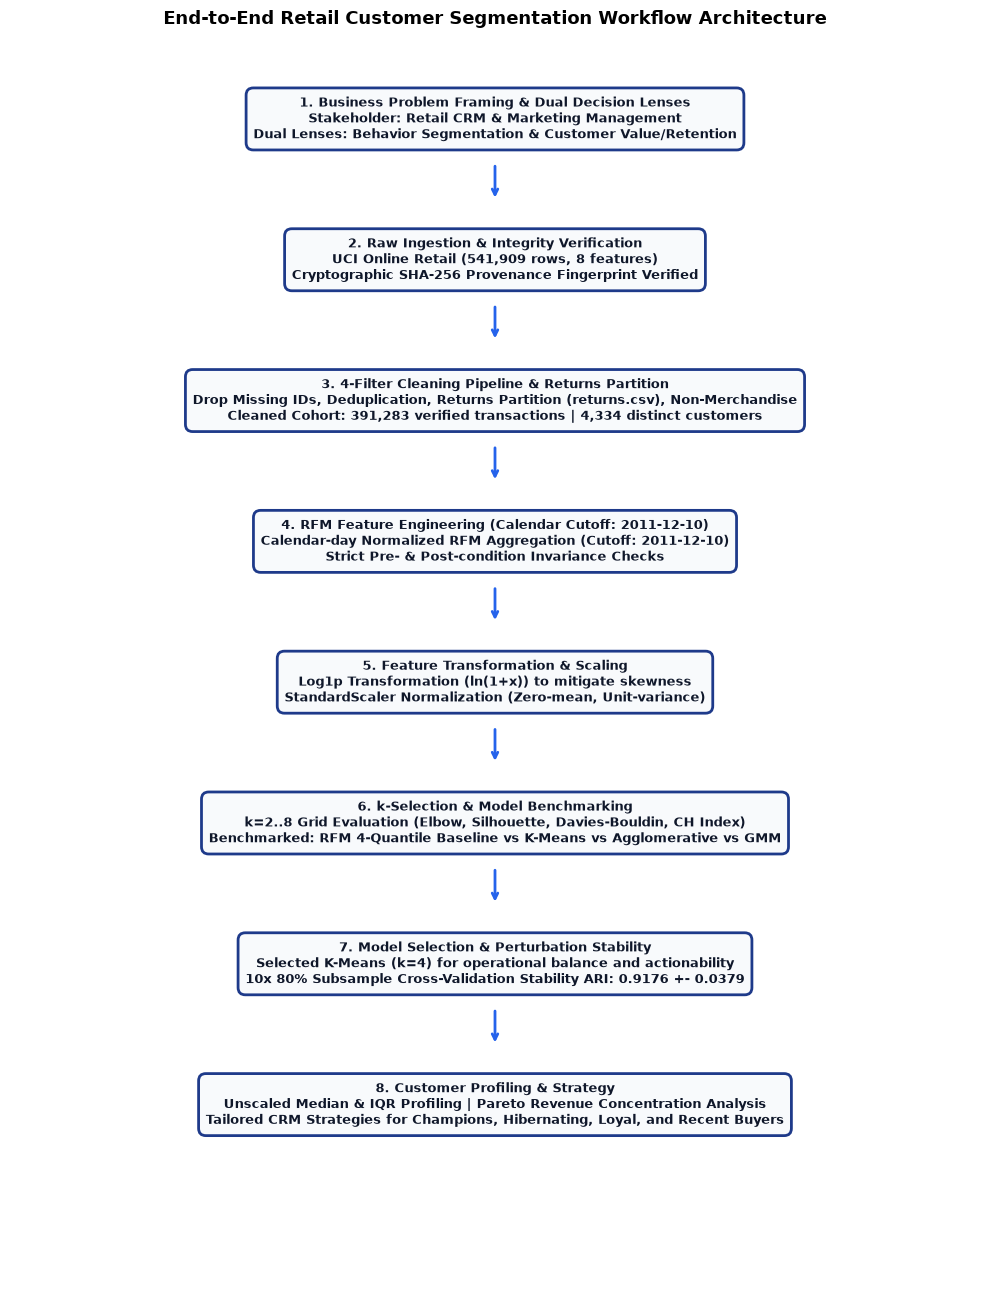

Correctly saved to root folder: ..\outputs\figures\workflow_diagram.png


In [16]:
import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 13))
ax.axis("off")

steps = [
    ("1. Business Problem Framing & Dual Decision Lenses", 
     "Stakeholder: Retail CRM & Marketing Management\nDual Lenses: Behavior Segmentation & Customer Value/Retention"),
    ("2. Raw Ingestion & Integrity Verification", 
     "UCI Online Retail (541,909 rows, 8 features)\nCryptographic SHA-256 Provenance Fingerprint Verified"),
    ("3. 4-Filter Cleaning Pipeline & Returns Partition", 
     "Drop Missing IDs, Deduplication, Returns Partition (returns.csv), Non-Merchandise\nCleaned Cohort: 391,283 verified transactions | 4,334 distinct customers"),
    ("4. RFM Feature Engineering (Calendar Cutoff: 2011-12-10)", 
     "Calendar-day Normalized RFM Aggregation (Cutoff: 2011-12-10)\nStrict Pre- & Post-condition Invariance Checks"),
    ("5. Feature Transformation & Scaling", 
     "Log1p Transformation (ln(1+x)) to mitigate skewness\nStandardScaler Normalization (Zero-mean, Unit-variance)"),
    ("6. k-Selection & Model Benchmarking", 
     "k=2..8 Grid Evaluation (Elbow, Silhouette, Davies-Bouldin, CH Index)\nBenchmarked: RFM 4-Quantile Baseline vs K-Means vs Agglomerative vs GMM"),
    ("7. Model Selection & Perturbation Stability", 
     "Selected K-Means (k=4) for operational balance and actionability\n10x 80% Subsample Cross-Validation Stability ARI: 0.9176 +- 0.0379"),
    ("8. Customer Profiling & Strategy", 
     "Unscaled Median & IQR Profiling | Pareto Revenue Concentration Analysis\nTailored CRM Strategies for Champions, Hibernating, Loyal, and Recent Buyers")
]

y_pos = 0.94
box_height = 0.072
spacing = 0.042

for i, (title, desc) in enumerate(steps):
    bbox_props = dict(boxstyle="round,pad=0.55", fc="#F8FAFC", ec="#1E3A8A", lw=2)
    ax.text(0.5, y_pos, f"{title}\n{desc}", ha="center", va="center", 
            fontsize=9.5, weight="bold", color="#0F172A", bbox=bbox_props)
    
    if i < len(steps) - 1:
        ax.annotate('', xy=(0.5, y_pos - box_height/2 - spacing + 0.012), 
                    xytext=(0.5, y_pos - box_height/2),
                    arrowprops=dict(arrowstyle="->", lw=2, color="#2563EB"))
    y_pos -= (box_height + spacing)

plt.title("End-to-End Retail Customer Segmentation Workflow Architecture", fontsize=13, weight="bold", pad=15)
plt.tight_layout()

# Notebook එක ඇතුළේ ඉඳන් root එකේ තියෙන outputs/figures වලට save කිරීම:
save_path = os.path.join('..', 'outputs', 'figures', 'workflow_diagram.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Correctly saved to root folder: {save_path}")

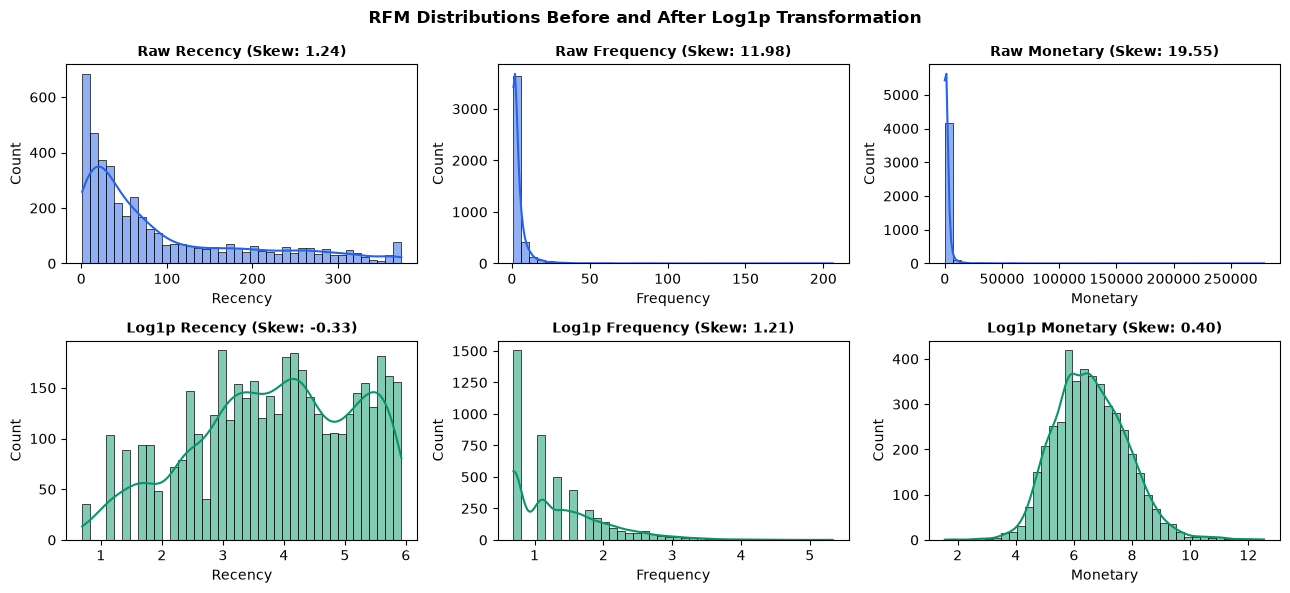

Successfully saved: ..\outputs\figures\log1p_distribution_comparison.png


In [22]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Identify the active RFM dataframe in your notebook session
if 'rfm_df' in globals():
  data_df = rfm_df
elif 'df_rfm' in globals():
  data_df = df_rfm
elif 'customer_df' in globals():
  data_df = customer_df
else:
  raise NameError(
      'Could not find RFM dataframe. Please verify your dataframe variable'
      ' name in earlier cells.'
  )

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

features = ['Recency', 'Frequency', 'Monetary']
colors_raw = ['#2563EB', '#2563EB', '#2563EB']
colors_log = ['#059669', '#059669', '#059669']

for i, col in enumerate(features):
  # Plot raw feature distribution
  sns.histplot(
      data_df[col], bins=40, kde=True, ax=axes[0, i], color=colors_raw[i]
  )
  axes[0, i].set_title(
      f'Raw {col} (Skew: {data_df[col].skew():.2f})', fontsize=10, weight='bold'
  )

  # Plot log1p transformed distribution
  log_vals = np.log1p(data_df[col])
  sns.histplot(log_vals, bins=40, kde=True, ax=axes[1, i], color=colors_log[i])
  axes[1, i].set_title(
      f'Log1p {col} (Skew: {log_vals.skew():.2f})', fontsize=10, weight='bold'
  )

plt.suptitle(
    'RFM Distributions Before and After Log1p Transformation',
    fontsize=12,
    weight='bold',
)
plt.tight_layout()

# Save figure directly into the project root outputs/figures directory
save_path_eda = os.path.join(
    '..', 'outputs', 'figures', 'log1p_distribution_comparison.png'
)
plt.savefig(save_path_eda, dpi=300, bbox_inches='tight')
plt.show()
print(f'Successfully saved: {save_path_eda}')

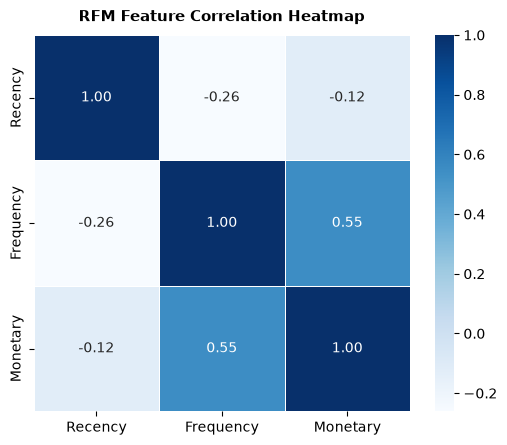

Successfully saved: ..\outputs\figures\rfm_correlation_heatmap.png


In [23]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Select the active RFM dataframe
data_df = rfm_df if 'rfm_df' in globals() else df_rfm

plt.figure(figsize=(5.5, 4.5))
corr = data_df[['Recency', 'Frequency', 'Monetary']].corr()

# Render pairwise correlation matrix
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    cbar=True,
    square=True,
    linewidths=0.5,
)
plt.title('RFM Feature Correlation Heatmap', fontsize=11, weight='bold', pad=10)
plt.tight_layout()

# Save figure to outputs/figures directory
save_path_corr = os.path.join(
    '..', 'outputs', 'figures', 'rfm_correlation_heatmap.png'
)
plt.savefig(save_path_corr, dpi=300, bbox_inches='tight')
plt.show()
print(f'Successfully saved: {save_path_corr}')

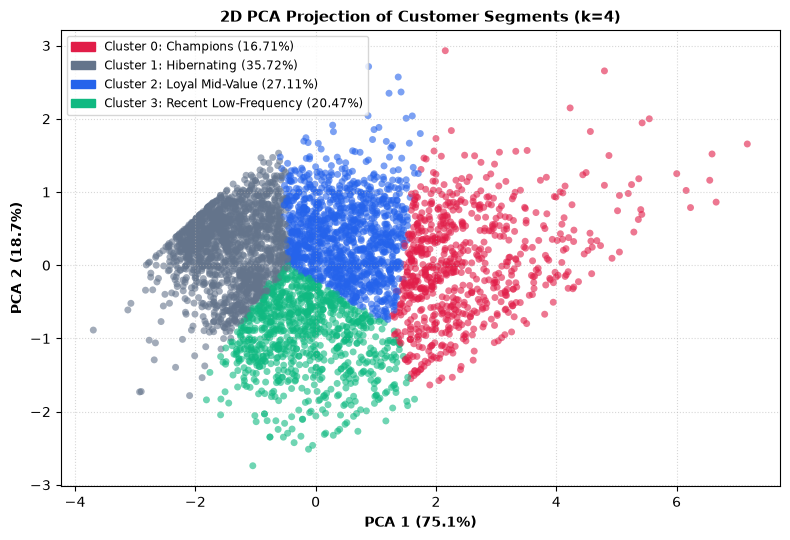

Successfully saved: ..\outputs\figures\cluster_scatter_pca.png


In [25]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Resolve standardized features matrix
if 'X_scaled' in globals():
    data_scaled = X_scaled
elif 'scaled_features' in globals():
    data_scaled = scaled_features
else:
    raise NameError("Could not find 'X_scaled'. Please verify the scaled feature variable name.")

# 2. Resolve cluster labels
if 'km_model' in globals():
    cluster_labels = km_model.labels_
elif 'kmeans' in globals():
    cluster_labels = kmeans.labels_
elif 'kmeans_model' in globals():
    cluster_labels = kmeans_model.labels_
elif 'rfm_df' in globals() and 'Cluster' in rfm_df.columns:
    cluster_labels = rfm_df['Cluster'].values
elif 'df_rfm' in globals() and 'Cluster' in df_rfm.columns:
    cluster_labels = df_rfm['Cluster'].values
else:
    # Fallback: fit K-Means (k=4) reproducibly
    kmeans_fallback = KMeans(n_clusters=4, random_state=42, n_init=10).fit(data_scaled)
    cluster_labels = kmeans_fallback.labels_

# 3. Fit 2D PCA projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(data_scaled)

# 4. Color scheme and persona mapping
colors = {0: '#E11D48', 1: '#64748B', 2: '#2563EB', 3: '#10B981'}
labels_map = {
    0: 'Cluster 0: Champions (16.71%)',
    1: 'Cluster 1: Hibernating (35.72%)',
    2: 'Cluster 2: Loyal Mid-Value (27.11%)',
    3: 'Cluster 3: Recent Low-Frequency (20.47%)'
}

plt.figure(figsize=(8, 5.5))
point_colors = [colors[int(c)] for c in cluster_labels]

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=point_colors,
    alpha=0.6,
    s=25,
    edgecolors='none'
)

legend_patches = [mpatches.Patch(color=colors[k], label=labels_map[k]) for k in sorted(colors)]
plt.legend(handles=legend_patches, loc='best', frameon=True, fontsize=8.5)

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', weight='bold')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', weight='bold')
plt.title('2D PCA Projection of Customer Segments (k=4)', fontsize=11, weight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# 5. Save directly to root outputs/figures
save_path_pca = os.path.join('..', 'outputs', 'figures', 'cluster_scatter_pca.png')
plt.savefig(save_path_pca, dpi=300, bbox_inches='tight')
plt.show()
print(f"Successfully saved: {save_path_pca}")

In [26]:
from sklearn.cluster import KMeans
import pandas as pd

# Verify k=2, 3, 4 profiles directly on unscaled data
for k_val in [2, 3, 4]:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10).fit(X_scaled)
    temp_df = data_df[['Recency', 'Frequency', 'Monetary']].copy()
    temp_df['Cluster'] = km.labels_
    
    summary = temp_df.groupby('Cluster').agg(
        Count=('Monetary', 'count'),
        Customer_Share=('Monetary', lambda x: len(x) / len(temp_df) * 100),
        Recency_Median=('Recency', 'median'),
        Freq_Median=('Frequency', 'median'),
        Monetary_Median=('Monetary', 'median')
    )
    print(f"\n--- k = {k_val} Profile ---")
    print(summary.round(2))


--- k = 2 Profile ---
         Count  Customer_Share  Recency_Median  Freq_Median  Monetary_Median
Cluster                                                                     
0         2671           61.63            97.0          1.0           357.98
1         1663           38.37            17.0          6.0          2039.58

--- k = 3 Profile ---
         Count  Customer_Share  Recency_Median  Freq_Median  Monetary_Median
Cluster                                                                     
0          750           17.31            10.0         10.0          3639.99
1         1874           43.24           160.0          1.0           293.78
2         1710           39.46            30.0          3.0           964.79

--- k = 4 Profile ---
         Count  Customer_Share  Recency_Median  Freq_Median  Monetary_Median
Cluster                                                                     
0          724           16.71             9.0         10.0          3596.85
1      